<a href="https://colab.research.google.com/github/BBilgeKaplan/VeriAnaliziOkulu/blob/main/Veri_Analiz_Okulu%2C_Yapay_Zeka__Makina_%C3%96%C4%9Frenmesi%2C_Ders_10_Uygulama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Veri Analizi Okulu – Yapay Zeka
## Derin Öğrenme

**Hazırlayan:** Emre Fişne  
**Kurum:** Boğaziçi Üniversitesi / Veri Bilimi ve Yapay Zeka Enstitüsü
**Tarih:** 10 Nisan 2026

---

Bu notebook, derin öğrenmenin temel fikirlerini pratik örnekler üzerinden tanıtmak amacıyla hazırlanmıştır.
İçerikte gradyan kavramlarından başlayarak, yapay sinir ağları, backpropagation ve modern derin öğrenme yapı taşlarına uzanan örnekler yer almaktadır.

## İçindekiler
1. Türev ve sezgisel anlamı
2. Sayısal türev yaklaşımı
3. Gradyan ve optimizasyon fikri
4. Basit nöron modeli
5. Çok katmanlı algılayıcı (MLP)
6. Eğitim mantığı ve loss
7. PyTorch ile temel eğitim döngüsü
8. Transformer mantığına giriş
9. Basit GPT modeli eğitimi

## Öğrenme Hedefleri
Bu notebook sonunda:
- türev ve gradyanın neden önemli olduğunu,
- bir sinir ağının temel çalışma mantığını,
- geri yayılımın neyi hesapladığını,
- PyTorch ile basit bir modelin nasıl eğitildiğini,
- transformer yapısının temel sezgisini

anlıyor olmanız hedeflenmektedir.

# *Kısım 1*

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

##  Türev: Bir Fonksiyonun Türevi <a id="001"></a>
------
Bir fonksiyon tanımlayıp görselleştirelim.

$$
f(x) = \left(5x^2 + 3\right)^{\frac{1}{2}}
$$

In [ ]:
def f(x):
    return (5*x**2 + 3)**0.5

In [ ]:
f(3.0)

6.928203230275509

In [ ]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [ ]:
ys = f(xs)
ys

array([11.3137085 , 10.76162163, 10.21028893,  9.65983954,  9.11043358,
        8.56227189,  8.01560977,  7.4707764 ,  6.92820323,  6.38846617,
        5.85234996,  5.32094916,  4.79583152,  4.27931069,  3.77491722,
        3.28823661,  2.82842712,  2.41091269,  2.06155281,  1.82002747,
        1.73205081,  1.82002747,  2.06155281,  2.41091269,  2.82842712,
        3.28823661,  3.77491722,  4.27931069,  4.79583152,  5.32094916,
        5.85234996,  6.38846617,  6.92820323,  7.4707764 ,  8.01560977,
        8.56227189,  9.11043358,  9.65983954, 10.21028893, 10.76162163])

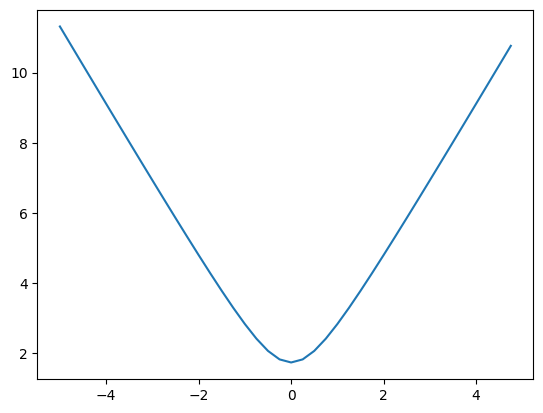

In [ ]:
plt.plot(xs, ys)
plt.show()

Bir Fonksiyonun Türevi Nedir? Eğer herhangi bir noktada X eksenindeki çok küçük bir değişikliğe fonksiyonun tepkisi nedir sorusunun cevabıdır.

$$
\frac{d f(x)}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

In [ ]:
h = 0.001
x = -2.0
(f(x + h) - f(x))/h

-2.085076117164242

In [ ]:
h = 0.000001
x = -3.0
(f(x + h) - f(x))/h

-2.1650634867143026

In [ ]:
h = 0.0000001
x = -3.0
türev = (f(x + h) - f(x))/h
türev

-2.165063506254228

# Fonksiyonun türevi için genel tanımı nasıl bulabiliriz: Zincir Kuralı

$$
\frac{dy}{dx} = \frac{dy}{du} \times \frac{du}{dx}
$$

Önce u = g(x) tanımlayalım

$$
g(x) = 5x^2 + 3
$$

In [ ]:
def g(x):
    return 5*x**2 + 3

In [ ]:
def f(x):
    return g(x)**(1/2)

In [ ]:
def g_türev_x(x):
    return 10 * x

$$
f'(g(x)) = \frac{1}{2}\,(g(x))^{-\frac{1}{2}}
$$

In [ ]:
def f_türev_gx(g, x):
    return (1/2) * (g(x)**(-1/2))

In [ ]:
def f_türev_x_zincir(x):
    return f_türev_gx(g, x) * g_türev_x(x)

In [ ]:
x = -3.0
print(f"x=-3'te türevi: {f_türev_x_zincir(x)}")

x=-3'te türevi: -2.1650635094610964


In [ ]:
f_türev_x_zincir(x) - türev

-3.2068685484887283e-09

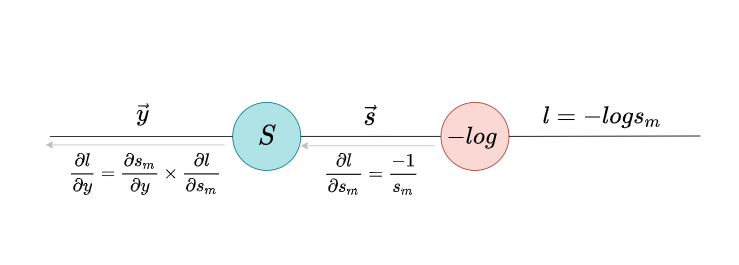

*https://medium.com/data-science/backpropagation-in-rnn-explained-bdf853b4e1c2*

In [ ]:
class Value:
    """ Bir skaler değeri ve gradyantını tutar """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0

        self._backward = lambda: None
        self._prev = set(_children)
        # bu değeri üreten operasyon (toplama? çarpma? sinüs?)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        t = math.exp(x)
        out = Value(t, (self,), 'exp')

        def _backward():
            self.grad += t * out.grad
        out._backward = _backward

        return out

    def backward(self):
      # düğümlerin graph yapısının oluşturulması
      # DFS (depth-first search)
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # her değişkenin gradyanını hesaplamak için
        # graph'ta geriye doğru gidiliyor
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __neg__(self): # -self
        return self * -1

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1


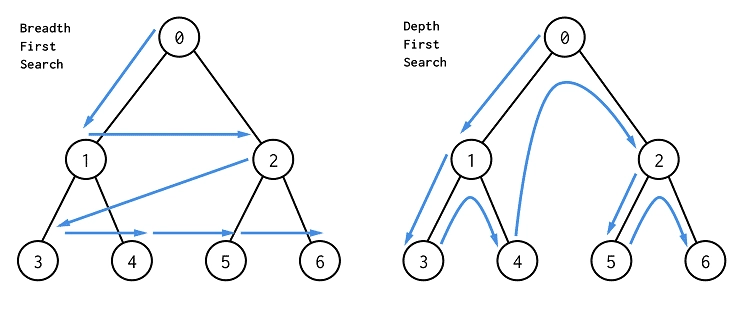

*https://dev.to/danimal92/difference-between-depth-first-search-and-breadth-first-search-6om*

In [ ]:
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')

d = a*b; d.label ='d'
L = d+c; L.label = 'L'
L
L._prev
L._op

'+'

In [ ]:
from graphviz import Digraph

def trace(root):
    """
    graph oluşturucu
    """
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # n1 düğümünü n2 düğümünün işlemiyle birleştirme
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

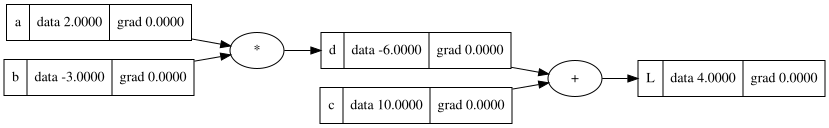

In [ ]:
draw_dot(L)

In [ ]:
L.backward()

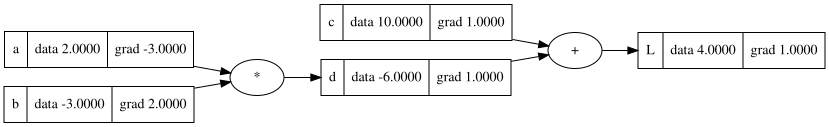

In [ ]:
draw_dot(L)

In [ ]:
print(f"L grad: {L.grad:.4f}") # dL/dL = 1.0
print(f"d grad: {d.grad:.4f}") # dL/dd = 1.0
print(f"c grad: {c.grad:.4f}") # dL/dc = 1.0
print(f"a grad: {a.grad:.4f}") # dL/da = (dL/dd) * (dd/da) = 1.0 * b.data
print(f"b grad: {b.grad:.4f}") # dL/db = (dL/dd) * (dd/db) = 1.0 * a.data

L grad: 1.0000
d grad: 1.0000
c grad: 1.0000
a grad: -3.0000
b grad: 2.0000


# Optimizasyon

In [ ]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
d.data += 0.01 * d.grad

d = a*b
L = d+c

print(L.data)

4.1394


**Nöron Yapısı**

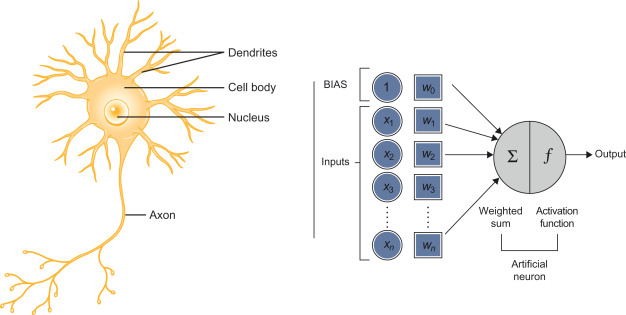

Chang, A. C. (2020). *Intelligence-based medicine: artificial intelligence and human cognition in clinical medicine and healthcare*. Academic Press.

In [ ]:
# girişler
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
# ağırlıklar
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
# bias
b = Value(6.8813735870195432,label='b')
# çıkış = x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label ='x1w1'
x2w2 = x2*w2; x2w2.label ='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh()
o.label = 'o'

In [ ]:
o.grad = 1.0           #do/do = 1

o._backward()          #do/dn
n._backward()          #do/db = do/d(x1w1+x2w2)
b._backward()
x1w1x2w2._backward()   #do/d(x1w1) = do/d(x2w2)
x2w2._backward()       #do/d(x2), do/d(w2)
x1w1._backward()       #do/d(x1), do/d(w1)

In [ ]:
o.grad

1.0

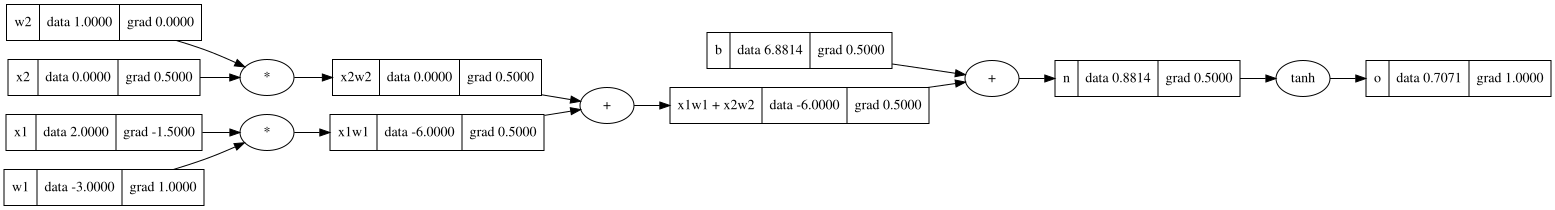

In [ ]:
draw_dot(o)

# *Kısım 2*

**PyTorch**

In [ ]:
import torch

torch.Tensor([[1, 2, 3], [4, 5, 6]]),\
torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape

(tensor([[1., 2., 3.],
         [4., 5., 6.]]),
 torch.Size([2, 3]))

In [ ]:
x1 = torch.tensor([2.0])    ;x1.requires_grad=True
w1 = torch.tensor([-3.0])   ;w1.requires_grad=True
x2 = torch.tensor([0.0])     ;x2.requires_grad=True
w2 = torch.tensor([1.0])     ;w2.requires_grad=True
b  = torch.tensor([6.8813735870195432])     ;b.requires_grad=True
n = w1*x1 + w2*x2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071067094802856
-----
x2 0.5000001192092896
w2 0.0
x1 -1.5000003576278687
w1 1.000000238418579


**Sinir Ağı Katmanları**

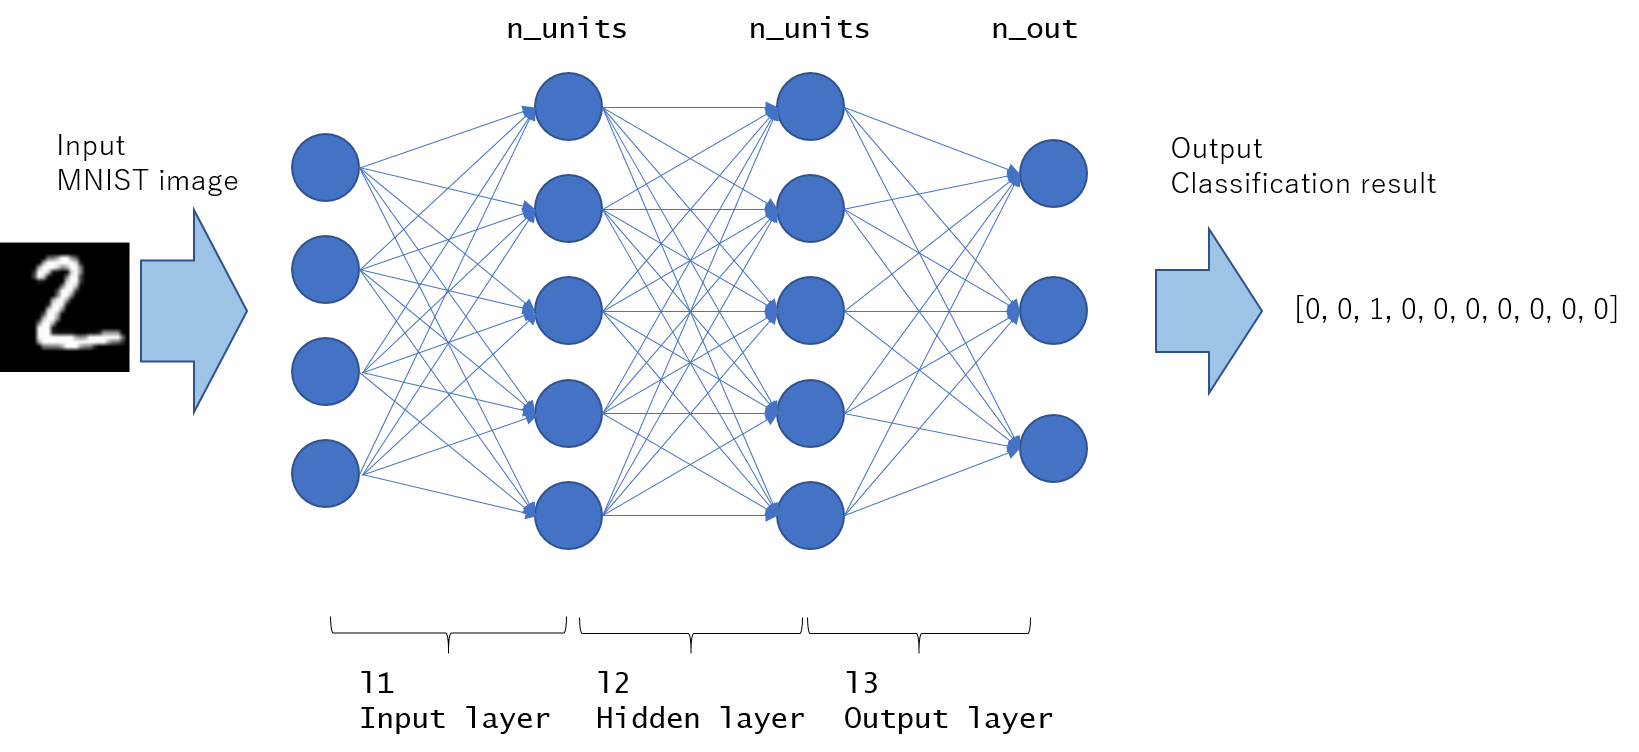

*https://corochann.com/mnist-training-with-multi-layer-perceptron-536/*

In [ ]:
import random

class Neuron:
    """ Yapay nöron sınıfı"""

    def __init__(self, nin):
        """ rastgele ağırlıklar ile başlar
        """
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x): # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)),  self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

In [ ]:
class Layer:
    """ Sinir ağı katmanı sınıfı """

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [param for neuron in self.neurons for param in neuron.parameters()]

In [ ]:
class MLP:
    """ Çok katmanlı yapay sinir ağı sınıfı"""

    def __init__(self, nin, nouts):
        """
        nin: int
            giriş boyutu
        nouts: list
            katman sayısı
        """
        sz = [nin] + nouts
        self.layers= [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]

In [ ]:
x = [2.0, 3.0]
a = Neuron(2)
a(x)

Value(data=0.9750995637050248, grad=0.0)

In [ ]:
x = [1.0, 1.0]
b =  Layer(2, 3)
b(x)

[Value(data=0.8299405558869526, grad=0.0),
 Value(data=-0.9896314177742245, grad=0.0),
 Value(data=-0.8328198551337482, grad=0.0)]

In [ ]:
# giriş
x = [2.0, 3.0, -1.0]

# yapay sinir ağı instance'ı
mlp = MLP(3, [4, 4, 1])

# forward pass
mlp(x)

Value(data=0.12727807904037555, grad=0.0)

In [ ]:
def Loss(prediction, target):
  loss = 0
  for target_, prediction_ in zip(target, prediction):
    loss += (prediction_ - target_)**2
  return loss

# Yapay Sinir Ağıyla Multiplexer Fonksiyonunu Öğrenmek

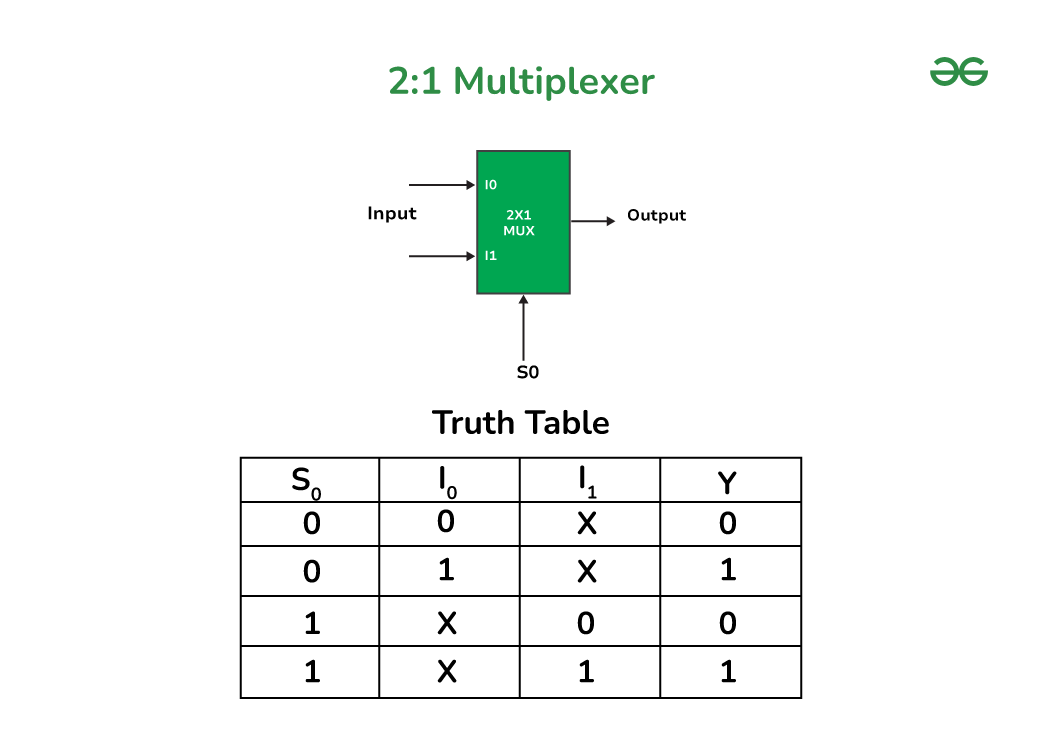

*https://www.geeksforgeeks.org/digital-logic/multiplexers-in-digital-logic/*

In [ ]:
# format: [giriş_A, giriş_B, kontrol]
x_data = [
    [ 1.0,  1.0, -1.0], # S=0, Output  A (1.0)
    [ 1.0, -1.0, -1.0], # S=0, Output  A (1.0)
    [-1.0,  1.0, -1.0], # S=0, Output  A (-1.0)
    [-1.0, -1.0, -1.0], # S=0, Output  A (-1.0)
    [ 1.0,  1.0,  1.0], # S=1, Output  B (1.0)
    [ 1.0, -1.0,  1.0], # S=1, Output  B (-1.0)
    [-1.0,  1.0,  1.0], # S=1, Output  B (1.0)
    [-1.0, -1.0,  1.0], # S=1, Output  B (-1.0)
]

# hedef ddeğerler (MUX çıkışları)
y_data = [1.0, 1.0, -1.0, -1.0, 1.0, -1.0, 1.0, -1.0]

In [ ]:
def train_MLP(n_iter=20, learning_rate=0.01):
    losses, steps = [], []
    step = 0
    for k in range(n_iter):
        step += 1
        steps.append(step)
        # forward pass
        ypred = [mlp(x) for x in x_data]
        total_loss = Loss(ypred, y_data)
        # total_loss = loss
        losses.append(total_loss.data)

        # gradyanlar resetlenir
        for p in mlp.parameters():
            p.grad = 0.0
        total_loss.backward()

        # parametre güncelleme
        for p in mlp.parameters():
            p.data += -1 * learning_rate * p.grad

        print(k, total_loss.data)
    return [steps, losses]

In [ ]:
_train_loss = train_MLP(40, 0.05)

0 13.983836913859665
1 9.317276354910376
2 6.870492600948767
3 5.746156717834862
4 5.150573548287906
5 4.67254809957898
6 4.281796680127548
7 3.967787974708581
8 3.700540037706354
9 3.453294388223429
10 3.2030089015416707
11 2.9341415218180846
12 2.6365843784368996
13 2.30717058099759
14 1.9544915657633486
15 1.6040939032000805
16 1.2912079407850983
17 1.0392986523370187
18 0.8492400372234327
19 0.7087327532334601
20 0.6039683598453891
21 0.524206034018787
22 0.46201827509752746
23 0.41242310690051825
24 0.3720640724467971
25 0.3386389033073587
26 0.3105327906040236
27 0.2865870306268454
28 0.26595203031886344
29 0.24799232729633297
30 0.23222395966439724
31 0.21827229095367878
32 0.20584302347454206
33 0.19470188773728886
34 0.18466015291920013
35 0.17556411675903466
36 0.16728736422416873
37 0.15972498450477887
38 0.1527891944095331
39 0.146405986188936


In [ ]:
mlp([ 1.0,  1.0, -1.0])

Value(data=0.9968183182046283, grad=0.0)

# Derin Öğrenme ile Sentiment Analizi (Burada kaldık)